In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import seaborn as sb
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
import skfuzzy as fuzz
import pylab
import sklearn.mixture as mixture
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import random
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans, AgglomerativeClustering

In [4]:
df = pd.read_csv('movies_2026.csv', encoding='latin-1')
pd.options.display.float_format = '{:,.0f}'.format

In [14]:
#Budget
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["budget_clean"] = df["budget"].replace(0, np.nan)

#revenue
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")
df["revenue_clean"] = df["revenue"].replace(0, np.nan)

#votecount
df["voteCount"] = pd.to_numeric(df["voteCount"], errors="coerce")
df["voteCount_clean"] = df["voteCount"].replace(0, np.nan)

In [21]:
#Popularity
df["popularity_cat"] = pd.qcut(df["popularity"], 4,
                               labels=["Muy Baja", "Baja", "Alta", "Muy Alta"],
                               duplicates="drop")

#Budget
df["budget_cat"] = pd.qcut(
    df["budget_clean"].dropna(),
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)
df["budget_cat"] = df["budget_cat"].astype(object)
df.loc[df["budget"] == 0, "budget_cat"] = "No Reportado"

#Revenue
df["revenue_cat"] = pd.qcut(
    df["revenue_clean"],
    q=3,
    labels=["Moderado", "Exitoso", "Blockbuster"],
    duplicates="drop"
)
df["revenue_cat"] = df["revenue_cat"].astype(object)
df.loc[df["revenue"] == 0, "revenue_cat"] = "Sin Ingresos"
df["revenue_cat"] = df["revenue_cat"].astype("category")

#Runtime
df["runtime_cat"] = pd.cut(df["runtime"],
                           bins=[0, 90, 120, 150, df["runtime"].max()],
                           labels=["Corta", "Media", "Larga", "Muy Larga"])

#Vote Average
df["voteAvg_cat"] = pd.cut(df["voteAvg"],
                           bins=[0,5,6.5,8,10],
                           labels=["Mala", "Regular", "Buena", "Excelente"])

#Vote Count
df["voteCount_rank"] = df["voteCount_clean"].rank(method="first")
df["voteCount_cat"] = pd.qcut(
    df["voteCount_rank"],
    q=3,
    labels=["Pocos Votos", "Medio", "Muchos Votos"]
)
df["voteCount_cat"] = df["voteCount_cat"].astype(object)
df.loc[df["voteCount"] == 0, "voteCount_cat"] = "Sin Votos"

#Actors Amount
df["actorsAmount_cat"] = pd.cut(df["actorsAmount"],
                                bins=[0,5,10,20,df["actorsAmount"].max()],
                                labels=["Elenco Pequeño", "Medio", "Grande", "Muy Grande"])

#Women Ratio
df["women_ratio"] = df["castWomenAmount"] / (
    df["castWomenAmount"] + df["castMenAmount"]
)
df["women_ratio"] = df["women_ratio"].fillna(0)

df["women_ratio_cat"] = pd.cut(df["women_ratio"],
                               bins=[-0.01, 0.3, 0.6, 1.01],
                               labels=["Mayoría Hombres", "Mixto", "Mayoría Mujeres"])

#Production Countries
df["productionCountries_cat"] = pd.cut(
    df["productionCountriesAmount"],
    bins=[0,1,3,df["productionCountriesAmount"].max()],
    labels=["Nacional", "Coproducción", "Multinacional"]
)

# Décadas
df["release_decade"] = ((df["releaseYear"] // 10) * 10).astype(str) + "s"

In [ ]:
cols_umap = [
    "popularity",
    "budget",
    "revenue",
    "runtime",
    "voteAvg",
    "voteCount",
    "actorsAmount",
    "productionCountriesAmount",
    "genresAmount"
]

X = df[cols_umap].copy()
X = X.fillna(0)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cols_umap])

In [18]:
import umap.umap_ as umap

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_scaled)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


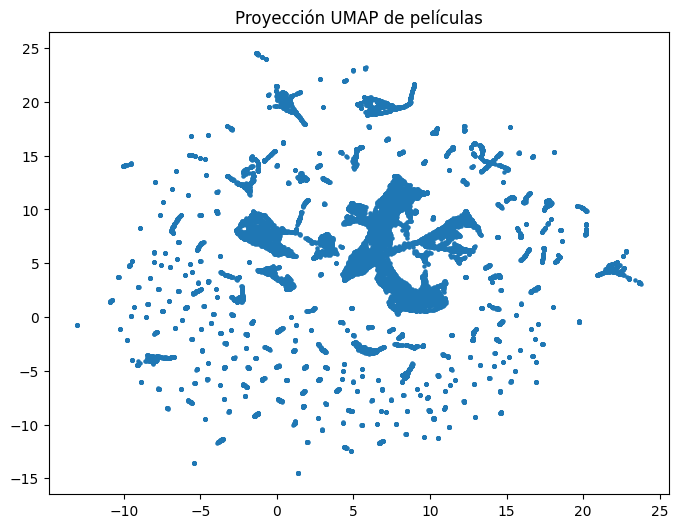

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(embedding[:,0], embedding[:,1], s=5)
plt.title("Proyección UMAP de películas")
plt.show()

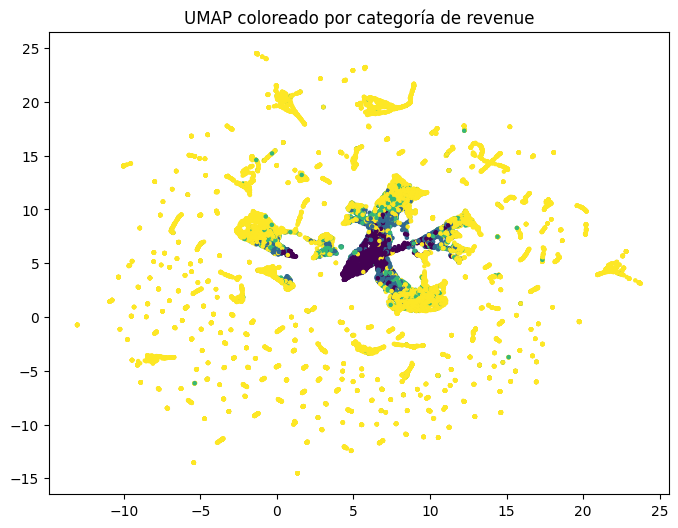

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=df["revenue_cat"].cat.codes,
    cmap="viridis",
    s=5
)
plt.title("UMAP coloreado por categoría de revenue")
plt.show()